In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
data_path = Path("../data/features/swiggy_features.csv")

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (45593, 18)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Distance_km              45593 non-null  float64
 1   order_hour               43862 non-null  float64
 2   day_of_week              45593 non-null  int64  
 3   month                    45593 non-null  int64  
 4   is_weekend               45593 non-null  int64  
 5   is_peak_hour             45593 non-null  int64  
 6   pickup_delay_minutes     43862 non-null  float64
 7   Delivery_person_Age      45593 non-null  int64  
 8   Delivery_person_Ratings  45593 non-null  float64
 9   Vehicle_condition        45593 non-null  int64  
 10  multiple_deliveries      45593 non-null  int64  
 11  Weatherconditions        44977 non-null  str    
 12  Road_traffic_density     45593 non-null  str    
 13  Type_of_order            45593 non-null  str    
 14  Type_of_vehicle          45593 no

In [8]:
df.isnull().sum()

Distance_km                   0
order_hour                 1731
day_of_week                   0
month                         0
is_weekend                    0
is_peak_hour                  0
pickup_delay_minutes       1731
Delivery_person_Age           0
Delivery_person_Ratings       0
Vehicle_condition             0
multiple_deliveries           0
Weatherconditions           616
Road_traffic_density          0
Type_of_order                 0
Type_of_vehicle               0
Festival                      0
City                          0
Time_taken(min)               0
dtype: int64

In [10]:
target_column = "Time_taken(min)"

X = df.drop(
    columns=[target_column]
)

y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45593, 17)
y shape: (45593,)


In [12]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [18]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (36474, 17)
Validation: (4559, 17)
Test: (4560, 17)


In [20]:
y_train.describe()

count    36474.000000
mean        26.301612
std          9.388823
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

<Axes: >

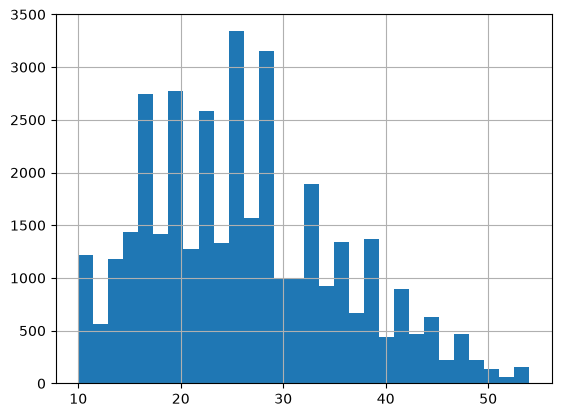

In [22]:
y_train.hist(bins=30)

In [24]:
numeric_features = [
    "Distance_km",
    "order_hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_peak_hour",
    "pickup_delay_minutes",
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries"
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 11
Categorical features: 6


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [28]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [30]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [35]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)

In [37]:
print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed validation shape:",
    X_val_processed.shape
)

print(
    "Processed test shape:",
    X_test_processed.shape
)

Processed training shape: (36474, 37)
Processed validation shape: (4559, 37)
Processed test shape: (4560, 37)


In [39]:
from sklearn.dummy import DummyRegressor

In [41]:
baseline_model = DummyRegressor(
    strategy="mean"
)

In [43]:
baseline_model.fit(
    X_train_processed,
    y_train
)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[26.3]]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,37
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [45]:
baseline_predictions = baseline_model.predict(
    X_val_processed
)

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [49]:
baseline_mae = mean_absolute_error(
    y_val,
    baseline_predictions
)

print(
    "Baseline MAE:",
    baseline_mae
)

Baseline MAE: 7.6336487148212795


In [51]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_val,
    baseline_predictions
)

print("Baseline Results")
print("----------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Baseline Results
----------------
MAE : 7.6336487148212795
RMSE: 9.394186474642192
R²  : -7.261756693166532e-05


In [53]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

rf_predictions = rf_model.predict(
    X_val_processed
)

In [56]:
rf_mae = mean_absolute_error(
    y_val,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_val,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 3.15761266353128
RMSE: 3.946709185554289
R²  : 0.8234842607721093


In [58]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
8,num__Delivery_person_Ratings,0.216294
10,num__multiple_deliveries,0.127844
19,cat__Road_traffic_density_Low,0.118292
0,num__Distance_km,0.116438
7,num__Delivery_person_Age,0.091601
15,cat__Weatherconditions_Sunny,0.074780
9,num__Vehicle_condition,0.073130
12,cat__Weatherconditions_Fog,0.044728
11,cat__Weatherconditions_Cloudy,0.043677
18,cat__Road_traffic_density_Jam,0.010571


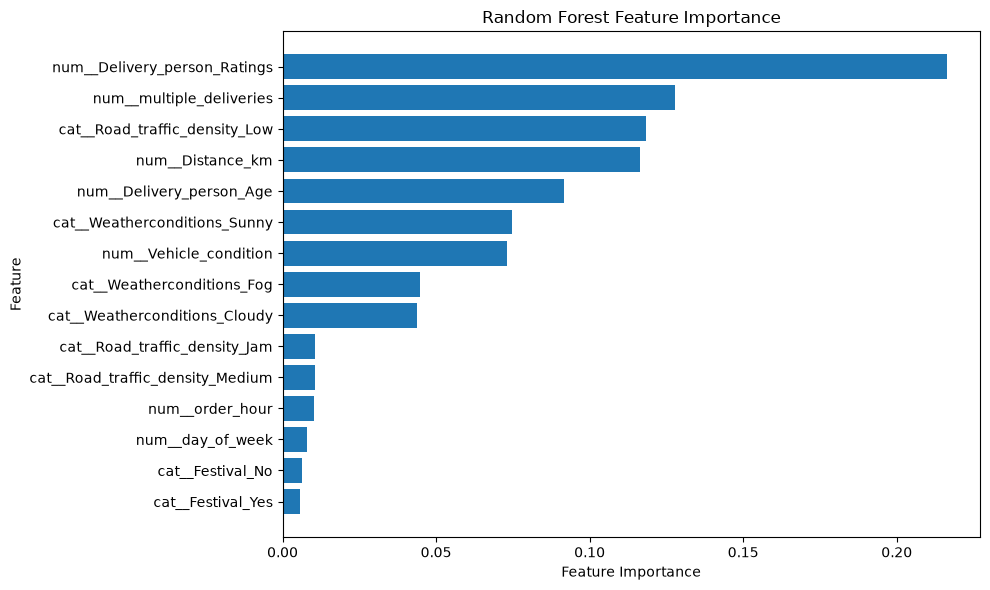

In [60]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.show()

In [62]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Baseline,7.633649,9.394186,-0.000073
1,Random Forest,3.157613,3.946709,0.823484


In [64]:
results.to_csv(
    "../data/features/model_comparison.csv",
    index=False
)


In [66]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [68]:
from xgboost import XGBRegressor

In [70]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [72]:
xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [74]:
xgb_predictions = xgb_model.predict(
    X_val_processed
)


In [76]:
xgb_mae = mean_absolute_error(
    y_val,
    xgb_predictions
)

print("XGBoost MAE:", xgb_mae)

XGBoost MAE: 3.1202051639556885


In [78]:
xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_val,
    xgb_predictions
)

print("XGBoost Results")
print("----------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost Results
----------------
MAE : 3.1202051639556885
RMSE: 3.9267221110973414
R²  : 0.8252675533294678


In [80]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2,
        xgb_r2
    ]
})

results.sort_values(
    "MAE"
)

,Model,MAE,RMSE,R2
2,XGBoost,3.120205,3.926722,0.825268
1,Random Forest,3.157613,3.946709,0.823484
0,Baseline,7.633649,9.394186,-0.000073


In [82]:
from sklearn.ensemble import GradientBoostingRegressor

In [84]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

In [85]:
gb_model.fit(
    X_train_processed,
    y_train
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [87]:
gb_predictions = gb_model.predict(
    X_val_processed
)

In [89]:
gb_mae = mean_absolute_error(
    y_val,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_val,
    gb_predictions
)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting Results
-------------------------
MAE : 3.565777773021092
RMSE: 4.460785779613677
R²  : 0.7745055183855807


In [91]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "XGBoost",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae,
        gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        gb_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2,
        xgb_r2,
        gb_r2
    ]
})

results.sort_values(
    "MAE"
)

,Model,MAE,RMSE,R2
2,XGBoost,3.120205,3.926722,0.825268
1,Random Forest,3.157613,3.946709,0.823484
3,Gradient Boosting,3.565778,4.460786,0.774506
0,Baseline,7.633649,9.394186,-0.000073


In [93]:
xgb_train_predictions = xgb_model.predict(
    X_train_processed
)

xgb_train_mae = mean_absolute_error(
    y_train,
    xgb_train_predictions
)

xgb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        xgb_train_predictions
    )
)

xgb_train_r2 = r2_score(
    y_train,
    xgb_train_predictions
)

print("XGBoost Training Results")
print("------------------------")
print("MAE :", xgb_train_mae)
print("RMSE:", xgb_train_rmse)
print("R²  :", xgb_train_r2)

print("\nXGBoost Validation Results")
print("--------------------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost Training Results
------------------------
MAE : 2.894451856613159
RMSE: 3.6322555279098605
R²  : 0.8503273725509644

XGBoost Validation Results
--------------------------
MAE : 3.1202051639556885
RMSE: 3.9267221110973414
R²  : 0.8252675533294678


In [95]:
xgb_errors = xgb_predictions - y_val

mean_error = xgb_errors.mean()

print("Mean Error:", mean_error)

Mean Error: 0.007261028570102793


In [97]:
overpredicted = (xgb_errors > 0).sum()
underpredicted = (xgb_errors < 0).sum()
exact = (xgb_errors == 0).sum()

total = len(xgb_errors)

print("Overpredicted :", overpredicted)
print("Underpredicted:", underpredicted)
print("Exact         :", exact)

print(
    "Overprediction %:",
    overpredicted / total * 100
)

print(
    "Underprediction %:",
    underpredicted / total * 100
)

Overpredicted : 2370
Underpredicted: 2189
Exact         : 0
Overprediction %: 51.98508444834393
Underprediction %: 48.01491555165606


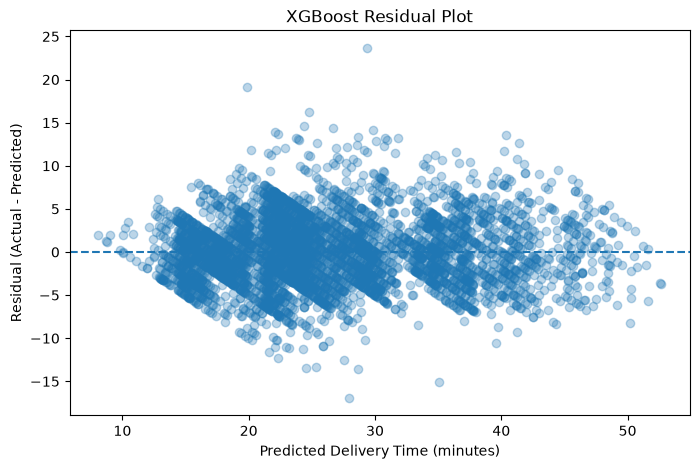

In [99]:
import matplotlib.pyplot as plt

residuals = y_val - xgb_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    xgb_predictions,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Delivery Time (minutes)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("XGBoost Residual Plot")

plt.show()

In [101]:
print("Mean Error:", xgb_errors.mean())
print("Median Error:", xgb_errors.median())

Mean Error: 0.007261028570102793
Median Error: 0.16820907592773438


In [103]:
feature_columns

NameError: name 'feature_columns' is not defined

In [105]:
print("Number of features:", X_train_processed.shape[1])
print("Original model columns:")
print(model_df.columns.tolist())

Number of features: 37
Original model columns:


NameError: name 'model_df' is not defined

In [107]:
print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [109]:
%whos

Variable                    Type                         Data/Info
------------------------------------------------------------------
ColumnTransformer           ABCMeta                      <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
DummyRegressor              type                         <class 'sklearn.dummy.DummyRegressor'>
GradientBoostingRegressor   ABCMeta                      <class 'sklearn.ensemble.<...>adientBoostingRegressor'>
OneHotEncoder               type                         <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Path                        type                         <class 'pathlib.Path'>
Pipeline                    ABCMeta                      <class 'sklearn.pipeline.Pipeline'>
RandomForestRegressor       ABCMeta                      <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
SimpleImputer               type                         <class 'sklearn.impute._base.SimpleImputer'>
X                           DataFrame      

In [111]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed features:")
for i, feature in enumerate(feature_names):
    print(i, feature)

Number of processed features: 37

Processed features:
0 num__Distance_km
1 num__order_hour
2 num__day_of_week
3 num__month
4 num__is_weekend
5 num__is_peak_hour
6 num__pickup_delay_minutes
7 num__Delivery_person_Age
8 num__Delivery_person_Ratings
9 num__Vehicle_condition
10 num__multiple_deliveries
11 cat__Weatherconditions_Cloudy
12 cat__Weatherconditions_Fog
13 cat__Weatherconditions_Sandstorms
14 cat__Weatherconditions_Stormy
15 cat__Weatherconditions_Sunny
16 cat__Weatherconditions_Windy
17 cat__Road_traffic_density_High
18 cat__Road_traffic_density_Jam
19 cat__Road_traffic_density_Low
20 cat__Road_traffic_density_Medium
21 cat__Road_traffic_density_Unknown
22 cat__Type_of_order_Buffet
23 cat__Type_of_order_Drinks
24 cat__Type_of_order_Meal
25 cat__Type_of_order_Snack
26 cat__Type_of_vehicle_bicycle
27 cat__Type_of_vehicle_electric_scooter
28 cat__Type_of_vehicle_motorcycle
29 cat__Type_of_vehicle_scooter
30 cat__Festival_No
31 cat__Festival_Unknown
32 cat__Festival_Yes
33 cat__Cit

In [113]:
print("Original features:")
print(X.columns.tolist())

Original features:
['Distance_km', 'order_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'pickup_delay_minutes', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']


In [115]:
for i, col in enumerate(X.columns):
    print(i, col)

0 Distance_km
1 order_hour
2 day_of_week
3 month
4 is_weekend
5 is_peak_hour
6 pickup_delay_minutes
7 Delivery_person_Age
8 Delivery_person_Ratings
9 Vehicle_condition
10 multiple_deliveries
11 Weatherconditions
12 Road_traffic_density
13 Type_of_order
14 Type_of_vehicle
15 Festival
16 City


In [117]:
X_initial = X.drop(
    columns=["pickup_delay_minutes"]
)

print("Original feature count:", X.shape[1])
print("Initial ETA feature count:", X_initial.shape[1])

print("\nInitial ETA features:")
for i, col in enumerate(X_initial.columns):
    print(i, col)

Original feature count: 17
Initial ETA feature count: 16

Initial ETA features:
0 Distance_km
1 order_hour
2 day_of_week
3 month
4 is_weekend
5 is_peak_hour
6 Delivery_person_Age
7 Delivery_person_Ratings
8 Vehicle_condition
9 multiple_deliveries
10 Weatherconditions
11 Road_traffic_density
12 Type_of_order
13 Type_of_vehicle
14 Festival
15 City


In [119]:
from sklearn.model_selection import train_test_split

X_initial_train, X_initial_temp, y_initial_train, y_initial_temp = train_test_split(
    X_initial,
    y,
    test_size=0.20,
    random_state=42
)

X_initial_val, X_initial_test, y_initial_val, y_initial_test = train_test_split(
    X_initial_temp,
    y_initial_temp,
    test_size=0.50,
    random_state=42
)

print("Training:", X_initial_train.shape)
print("Validation:", X_initial_val.shape)
print("Test:", X_initial_test.shape)

Training: (36474, 16)
Validation: (4559, 16)
Test: (4560, 16)


In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_initial_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_initial_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Distance_km', 'order_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries']

Categorical features:
['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']


In [123]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

initial_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [125]:
X_initial_train_processed = initial_preprocessor.fit_transform(
    X_initial_train
)

X_initial_val_processed = initial_preprocessor.transform(
    X_initial_val
)

X_initial_test_processed = initial_preprocessor.transform(
    X_initial_test
)

In [127]:
print(
    "Processed training:",
    X_initial_train_processed.shape
)

print(
    "Processed validation:",
    X_initial_val_processed.shape
)

print(
    "Processed test:",
    X_initial_test_processed.shape
)

Processed training: (36474, 36)
Processed validation: (4559, 36)
Processed test: (4560, 36)


In [129]:
from xgboost import XGBRegressor

xgb_initial_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [131]:
xgb_initial_model.fit(
    X_initial_train_processed,
    y_initial_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [133]:
xgb_initial_predictions = xgb_initial_model.predict(
    X_initial_val_processed
)

In [135]:
xgb_initial_mae = mean_absolute_error(
    y_initial_val,
    xgb_initial_predictions
)

xgb_initial_rmse = np.sqrt(
    mean_squared_error(
        y_initial_val,
        xgb_initial_predictions
    )
)

xgb_initial_r2 = r2_score(
    y_initial_val,
    xgb_initial_predictions
)

print("Production-Safe XGBoost")
print("-----------------------")
print("MAE :", xgb_initial_mae)
print("RMSE:", xgb_initial_rmse)
print("R²  :", xgb_initial_r2)

Production-Safe XGBoost
-----------------------
MAE : 3.125199556350708
RMSE: 3.9283219196303207
R²  : 0.8251251578330994


In [137]:
xgb_initial_test_predictions = xgb_initial_model.predict(
    X_initial_test_processed
)

In [139]:
final_mae = mean_absolute_error(
    y_initial_test,
    xgb_initial_test_predictions
)

print("Final Test MAE:", final_mae)

Final Test MAE: 3.158568859100342


In [141]:
final_rmse = np.sqrt(
    mean_squared_error(
        y_initial_test,
        xgb_initial_test_predictions
    )
)

final_r2 = r2_score(
    y_initial_test,
    xgb_initial_test_predictions
)

print("FINAL TEST RESULTS")
print("------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

FINAL TEST RESULTS
------------------
MAE : 3.158568859100342
RMSE: 3.9401423958156894
R²  : 0.8217302560806274


In [143]:
import joblib

joblib.dump(
    xgb_initial_model,
    "models/xgboost_eta_model.joblib"
)

FileNotFoundError: [Errno 2] No such file or directory: 'models/xgboost_eta_model.joblib'

In [145]:
import os

os.makedirs("models", exist_ok=True)

print("Models folder ready")

Models folder ready


In [147]:
import joblib

joblib.dump(
    xgb_initial_model,
    "models/xgboost_eta_model.joblib"
)

print("XGBoost model saved successfully")

XGBoost model saved successfully


In [149]:
joblib.dump(
    initial_preprocessor,
    "models/eta_preprocessor.joblib"
)

print("Preprocessor saved successfully")

Preprocessor saved successfully


In [151]:
import os

print(
    "Model:",
    os.path.exists("models/xgboost_eta_model.joblib")
)

print(
    "Preprocessor:",
    os.path.exists("models/eta_preprocessor.joblib")
)

Model: True
Preprocessor: True


In [153]:
import os

print(os.getcwd())

c:\Users\SAILAJA\delivery-ETA-prediction-sysystem\notebooks


In [155]:
print(os.path.abspath("models/xgboost_eta_model.joblib"))

c:\Users\SAILAJA\delivery-ETA-prediction-sysystem\notebooks\models\xgboost_eta_model.joblib
